In [1]:

import argparse
import os
import sys
import json
import logging
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

import torch
# from torch import nn
from torch import optim
from torch.utils.data import DataLoader

from dotenv import load_dotenv

from karhu import setup_logger
from karhu.training import plot_losses, plot_pred_vs_true, get_regression_scores

# Constants
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SCRIPT_DIR  = os.path.dirname("/scratch/project_2009007/ambrunc/dev_karhu/karhu/scripts")
SAVE_NAME   = f"model_{datetime.now():%Y%m%d_%H%M%S}"
SAVE_DIR    = os.path.join(SCRIPT_DIR, "../../models", SAVE_NAME)



In [2]:
import numpy as np
import matplotlib.pyplot as plt


def plot_scatter(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.4)

    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())

    plt.plot([mn, mx], [mn, mx], "r--")

    plt.xlabel("True")
    plt.ylabel("Predicted mean")
    plt.title("Prediction Accuracy")
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_with_uncertainty(y_true, y_mean, y_std, idx=0):
    y_true = np.asarray(y_true)[idx]
    y_mean = np.asarray(y_mean)[idx]
    y_std = np.asarray(y_std)[idx]

    x = np.arange(len(y_true))

    plt.figure(figsize=(10, 4))

    plt.plot(x, y_true, label="True", linewidth=2)
    plt.plot(x, y_mean, label="Pred mean", linewidth=2)

    plt.fill_between(
        x,
        y_mean - y_std,
        y_mean + y_std,
        alpha=0.3,
        label="±1σ",
    )

    plt.ylim(None, 1.1*np.max([0.03, np.max(y_true), np.max(y_mean+y_std)]))
    plt.legend()
    plt.title("Prediction + Uncertainty")
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_residuals(y_true, y_pred):
    residuals = np.asarray(y_pred).flatten() - np.asarray(y_true).flatten()

    plt.figure(figsize=(6, 4))
    plt.hist(residuals, bins=50, alpha=0.7)

    plt.axvline(0, color="red", linestyle="--")

    plt.xlabel("Error")
    plt.ylabel("Count")
    plt.title("Residual distribution")
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_uncertainty_calibration(y_true, y_pred, y_std):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    y_std = np.asarray(y_std).flatten()

    error = np.abs(y_true - y_pred)

    plt.figure(figsize=(6, 5))
    plt.scatter(y_std, error, s=8, alpha=0.3)

    plt.xlabel("Predicted σ (uncertainty)")
    plt.ylabel("Absolute error")
    plt.title("Uncertainty calibration")
    plt.grid()
    plt.tight_layout()
    plt.show()

def plot_random_predictions(
    y_true,
    y_mean,
    y_std,
    n_examples=5,
):
    n_examples = min(n_examples, len(y_true))

    idx = np.random.choice(
        len(y_true),
        n_examples,
        replace=False,
    )

    for i in idx:
        plot_with_uncertainty(y_true, y_mean, y_std, idx=i)
    return

## MLP

In [2]:
from karhu.gntor_mlp import GNtorPredictor, setup_dataset
from karhu.gntor_mlp import train_model, test_model, split_dataset, evaluate_model, predict

In [3]:
model_config = {
    "x_dim": 3*64+128+2,
    "y_dim": 8,
    "hidden_dims": (256,256,128,128,)
}
model = GNtorPredictor(**model_config)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

device = 'cpu'
dataset_dir = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/db/jet_2H/interpolated64.h5"
batch_size = 500
dataset, data_config = setup_dataset(dir_path=dataset_dir)

test_ratio = 0.10
train_ratio = 0.70
val_ratio = 0.20
train_data, val_data, test_data = split_dataset(
    dataset, train_ratio, val_ratio, test_ratio, base_seed=42)
    
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)


Epoch   1/100 | train=0.001555 | val=0.001515 | time=2.0s
Epoch   2/100 | train=0.001315 | val=0.001404 | time=1.0s
Epoch   3/100 | train=0.001338 | val=0.001371 | time=0.8s
Epoch   4/100 | train=0.001467 | val=0.001486 | time=0.7s
Epoch   5/100 | train=0.001402 | val=0.001578 | time=0.7s
Epoch   6/100 | train=0.001323 | val=0.003645 | time=0.7s
Epoch   7/100 | train=0.002043 | val=0.002138 | time=0.7s
Epoch   8/100 | train=0.001640 | val=0.001422 | time=0.7s
Epoch   9/100 | train=0.001466 | val=0.001305 | time=0.9s
Epoch  10/100 | train=0.001549 | val=0.008767 | time=0.7s
Epoch  11/100 | train=0.004520 | val=0.003424 | time=0.7s
Epoch  12/100 | train=0.002332 | val=0.001622 | time=0.7s
Epoch  13/100 | train=0.001412 | val=0.001656 | time=0.7s
Epoch  14/100 | train=0.001465 | val=0.002089 | time=0.7s
Epoch  15/100 | train=0.001748 | val=0.001533 | time=0.7s
Epoch  16/100 | train=0.001390 | val=0.001435 | time=0.9s
Epoch  17/100 | train=0.001263 | val=0.001458 | time=0.7s
Epoch  18/100 

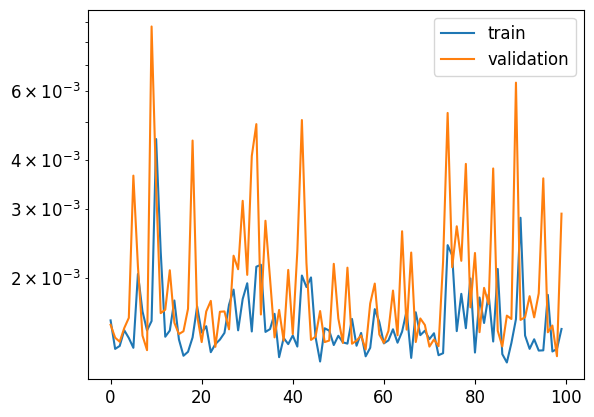

In [10]:

history = train_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    epochs=100,
    device=device,
)

train_losses = history["train_loss"]
val_losses = history["val_loss"]

# -------------------------
# Loss curves
# -------------------------
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.yscale("log")
plt.legend()
plt.show()


{'mse': np.float32(0.0017164061), 'mae': np.float32(0.023813616), 'mape': 0.0, 'r2': 0.9318982362747192}
{'mse': np.float32(0.00015881905), 'mae': np.float32(0.0072438037), 'mape': 0.0, 'r2': 0.9318988919258118}


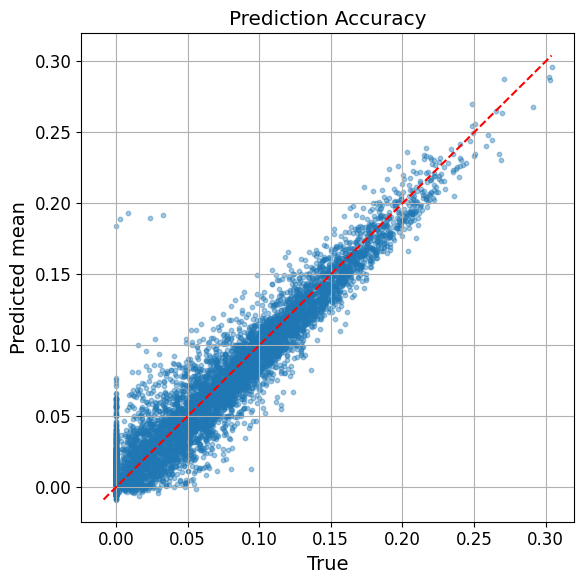

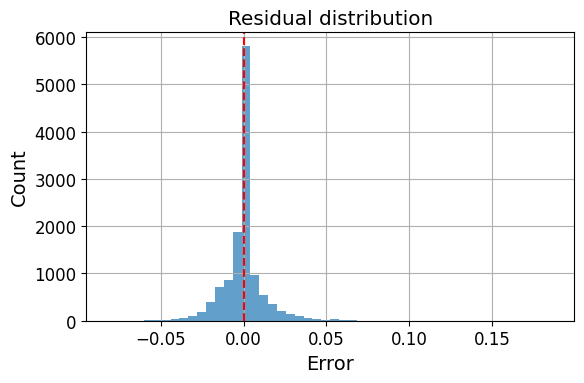

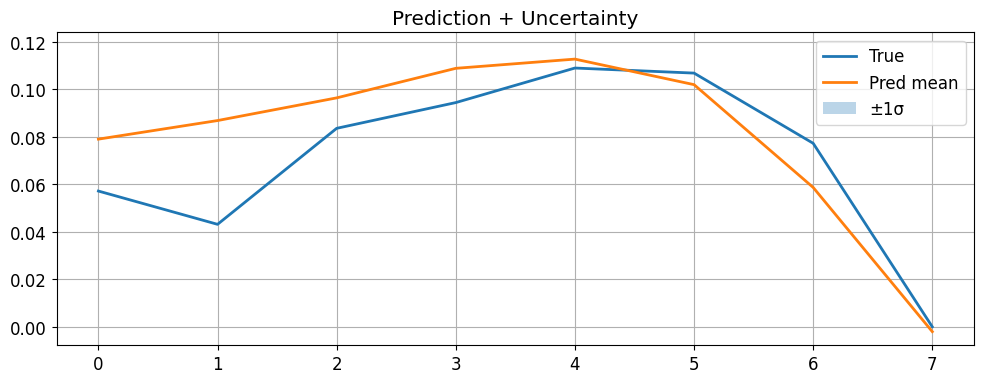

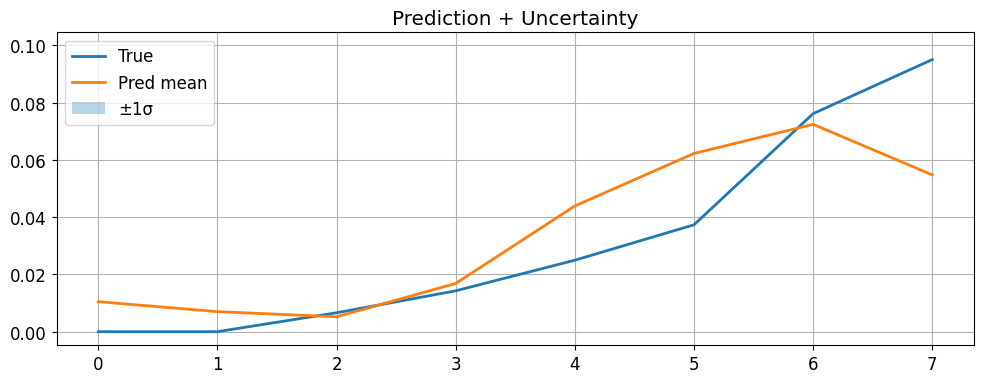

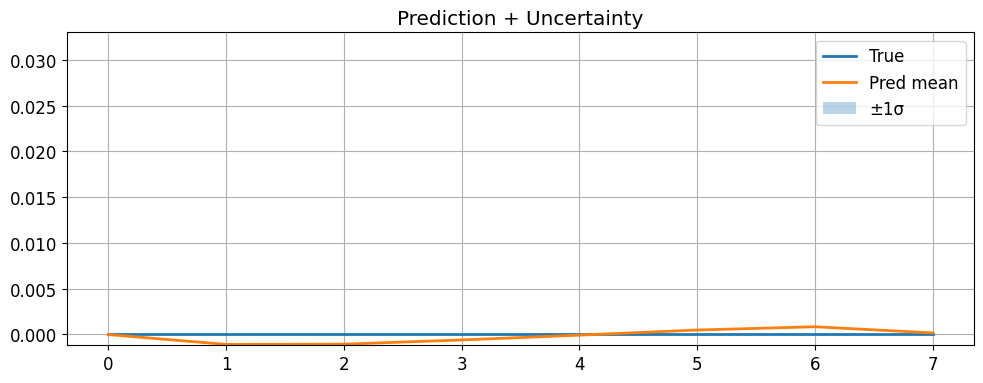

...

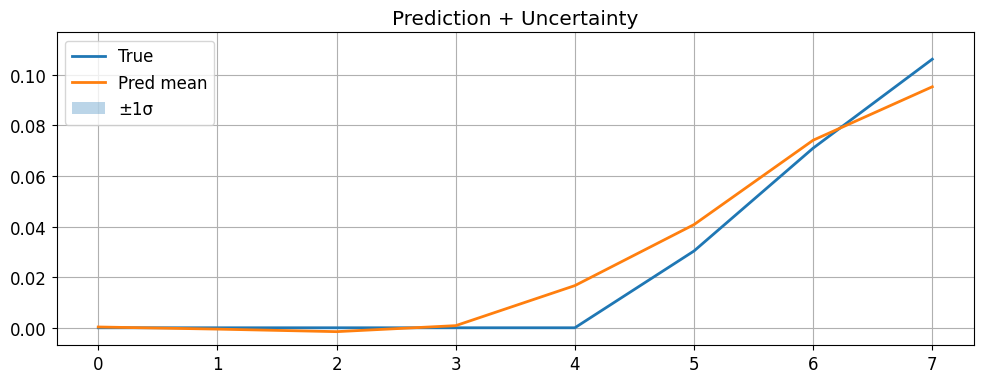

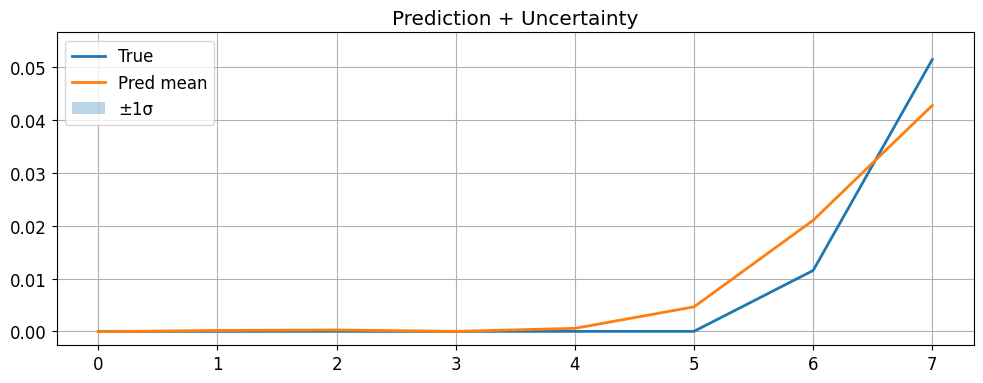

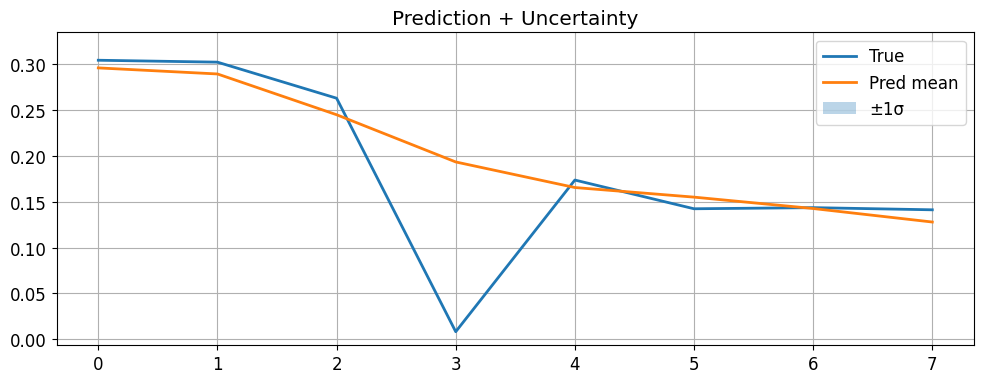

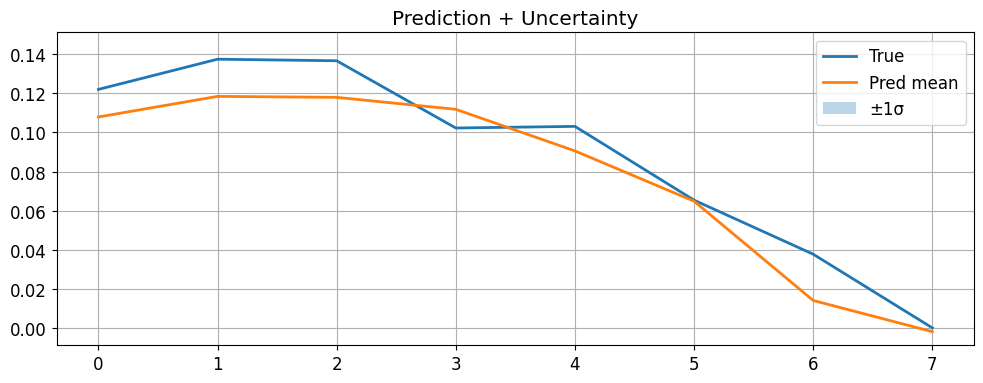

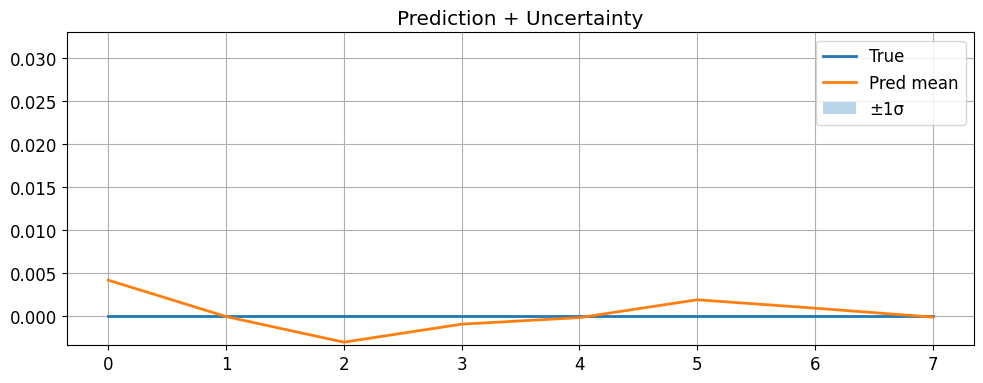

In [11]:
# get ONE batch
batch = next(iter(test_loader))

x_batch = batch["input"].to(device)
y_true = batch["output"].to(device)

# prediction
y_pred, y_std = predict(
    model,
    x_batch,
    device=device,
)

# convert to numpy
y_pred = y_pred.cpu().numpy()
y_true = y_true.cpu().numpy()

print(get_regression_scores(y_true, y_pred))

# unnormalize
y_pred = dataset.descale_minmax(
    y_pred,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

y_true = dataset.descale_minmax(
    y_true,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

print(get_regression_scores(y_true, y_pred))

# plots
plot_scatter(y_true, y_pred)
plot_residuals(y_true, y_pred)

plot_random_predictions(
    y_true,
    y_pred,
    y_std=np.zeros_like(y_pred),
    n_examples=50,
)


In [9]:

def save_config(save_dir, config):
    with open(
        os.path.join(save_dir, "model_config.json"), "w", encoding="utf-8"
    ) as f:
        json.dump(config, f, ensure_ascii=False, indent=4)


SAVE_NAME   = f"model_{datetime.now():%Y%m%d_%H%M%S}_mlp"
SAVE_DIR    = os.path.join("/scratch/project_2009007/ambrunc/dev_karhu/karhu/models", SAVE_NAME)
os.makedirs(SAVE_DIR, exist_ok=False)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "model.pt"))
dataset.save_scaling_params(SAVE_DIR)
config = data_config | model_config
save_config(SAVE_DIR, config)

## GNtor CNN

In [5]:
from karhu.gntor import GammaNtorPredictor, setup_dataset
from karhu.gntor import train_model, test_model, split_dataset, predict


model_config = {
    "conv_input_sizes": (64, 64, 64, 128),
    "scalar_inputs": 2,
    "scalar_outputs": 8,
    "conv_kernel_sizes": (7, 5, 3),
    "out_channels": 16,
    "pool_kernel_size": 2,
    "fc_hidden_dims": (256, 256, 256),
    "conv_dropout": 0.1,
    "fc_dropout": 0.1,
}
model = GammaNtorPredictor(model_config)
epochs = 100
optimizer = optim.Adam(model.parameters(), lr=1e-3)

Shape: tensor([[0.1425, 0.1428, 0.1282,  ..., 0.0455, 0.0170, 0.0048],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.0410, 0.0198, 0.0517,  ..., 0.0216, 0.0000, 0.0000],
        ...,
        [0.0247, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.2150, 0.2029, 0.1763,  ..., 0.1004, 0.0835, 0.0580],
        [0.1280, 0.1364, 0.1324,  ..., 0.0748, 0.0000, 0.0000]])


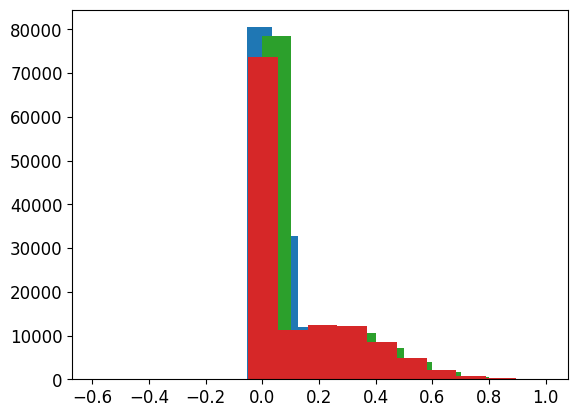

In [6]:

device = 'cpu'
dataset_dir = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/db/jet_2H/interpolated64.h5"
batch_size = 500
dataset, data_config = setup_dataset(dir_path=dataset_dir)

test_ratio = 0.10
train_ratio = 0.70
val_ratio = 0.20
train_data, val_data, test_data = split_dataset(
    dataset, train_ratio, val_ratio, test_ratio, base_seed=42)
    
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)

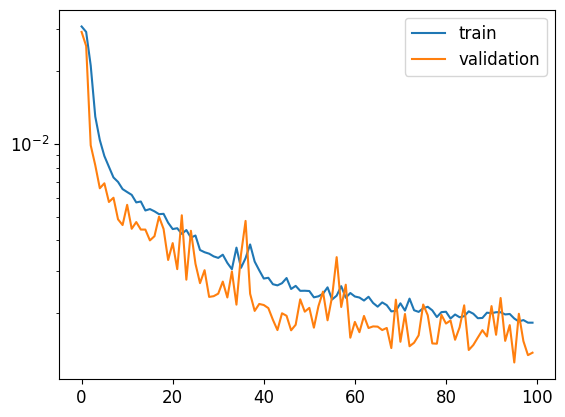

In [7]:

history = train_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    epochs=100,
    device=device,
)

train_losses = history["train_loss"]
val_losses = history["val_loss"]

# -------------------------
# Loss curves
# -------------------------
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.yscale("log")
plt.legend()
plt.show()


{'mse': np.float32(0.00012329505), 'mae': np.float32(0.005947417), 'mape': 0.0, 'r2': 0.9538114070892334}
{'mse': np.float32(1.14084905e-05), 'mae': np.float32(0.0018091296), 'mape': 0.0, 'r2': 0.9538112282752991}


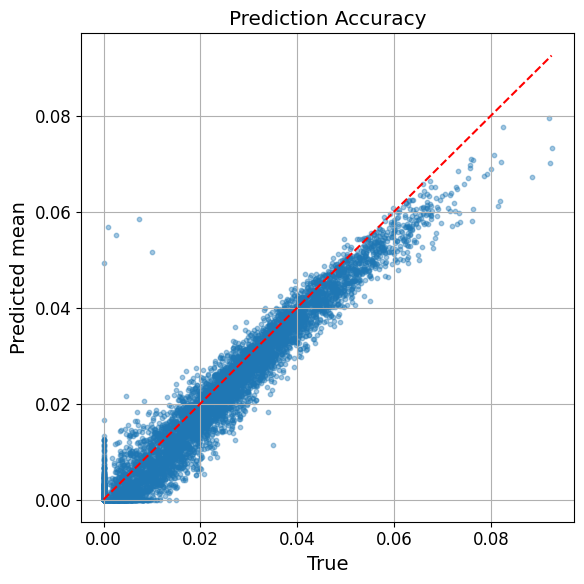

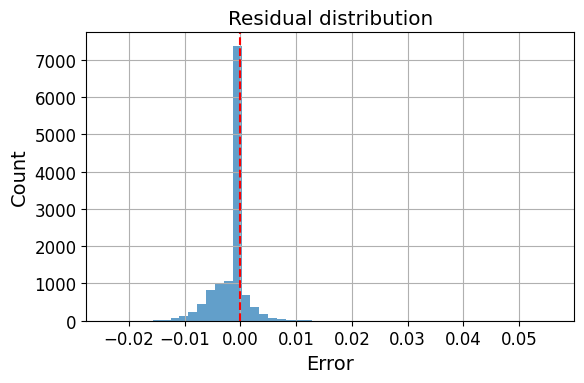

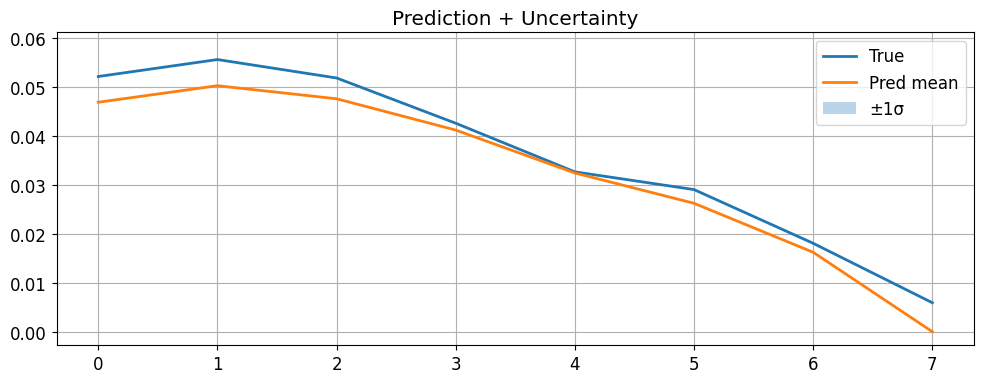

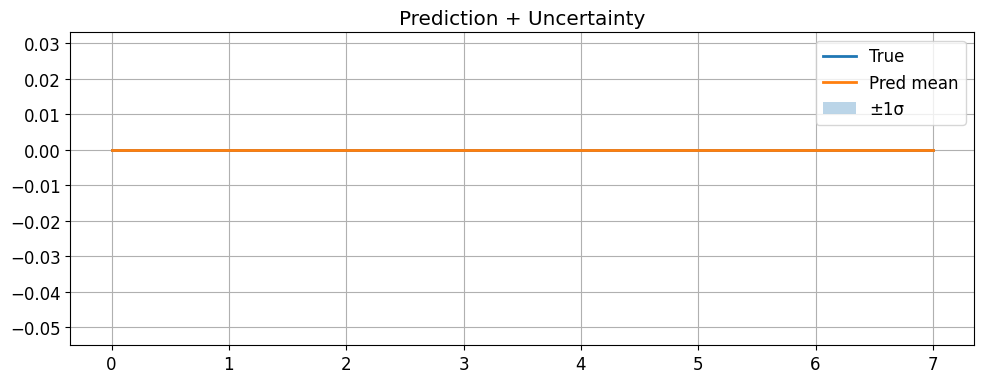

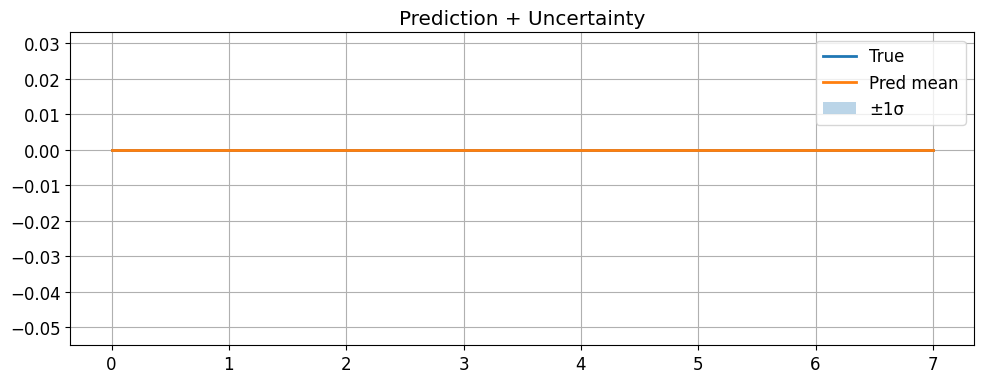

...

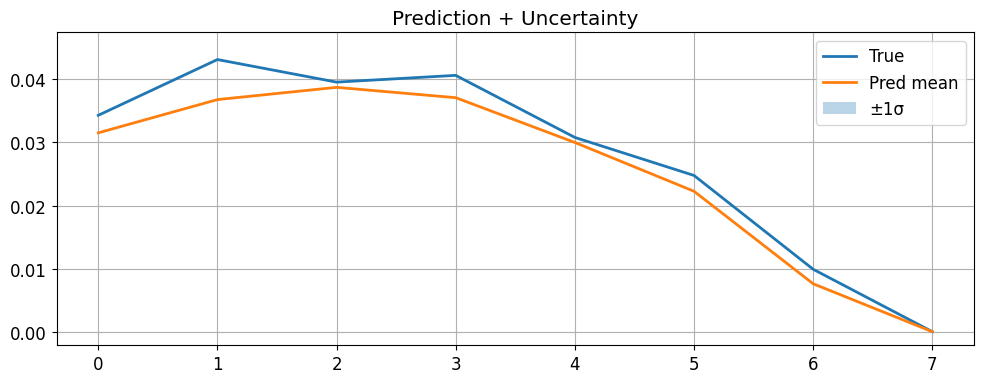

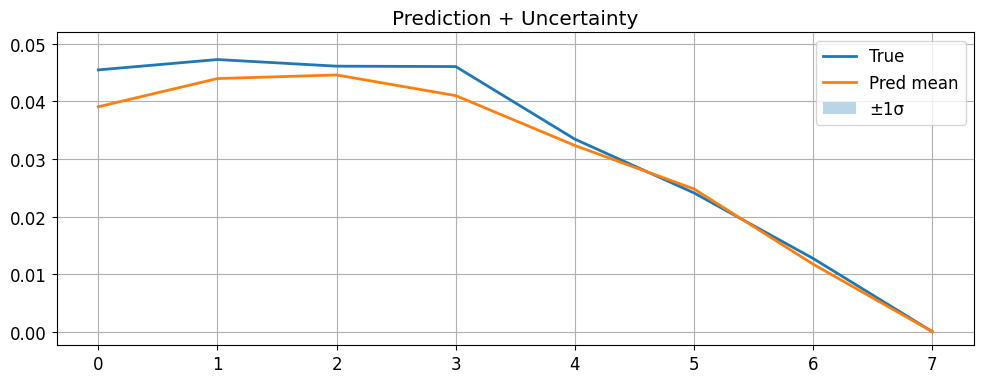

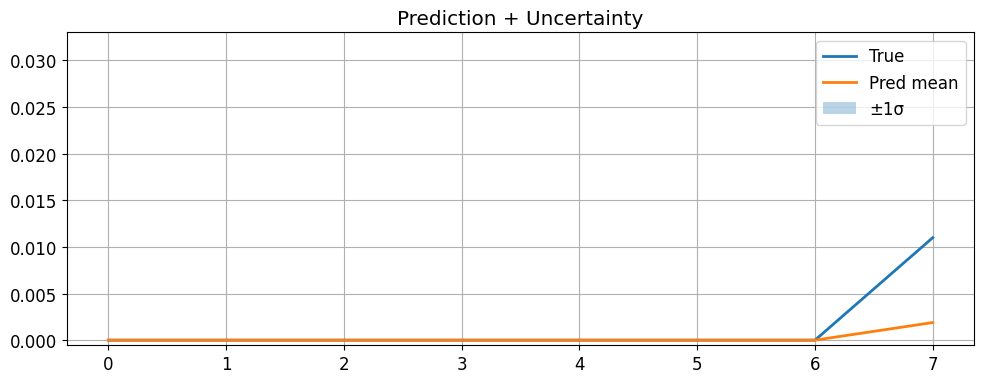

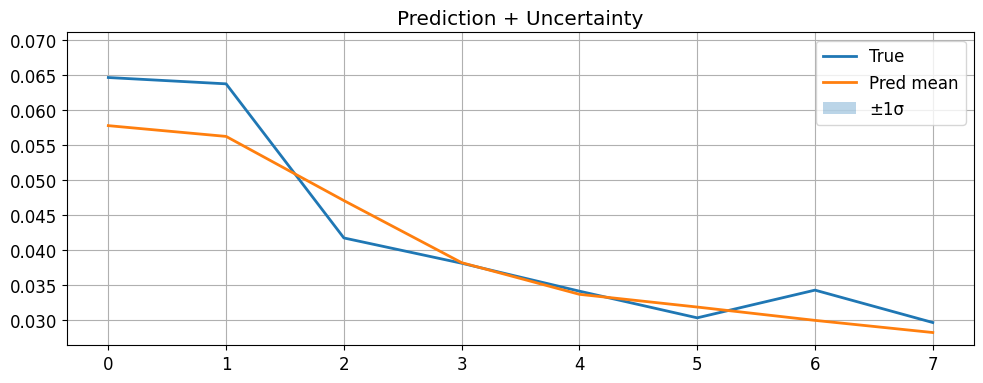

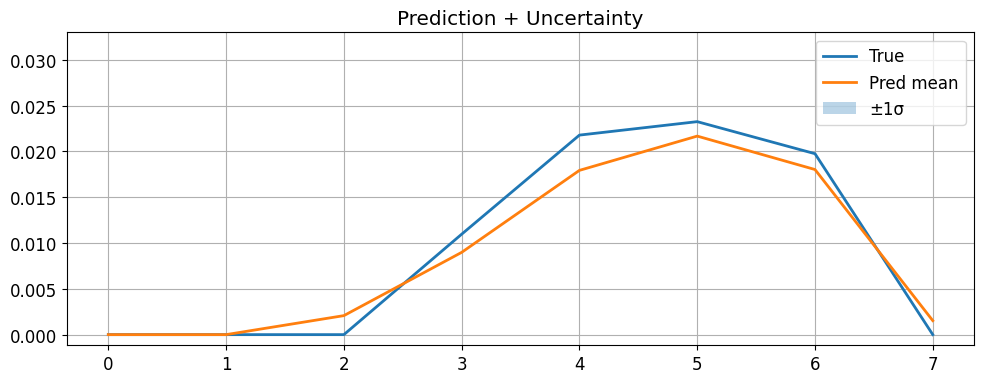

In [12]:
y_true, y_pred = test_model(model, test_loader, dataset)

# get ONE batch
# batch = next(iter(test_loader))

# x_batch = batch["input"].to(device)
# y_true = batch["output"].to(device)

# # prediction
# y_pred, y_std = predict(
#     model,
#     x_batch,
#     device=device,
# )

# # convert to numpy
# y_pred = y_pred.cpu().numpy()
# y_true = y_true.cpu().numpy()

print(get_regression_scores(y_true, y_pred))

# unnormalize
y_pred = dataset.descale_minmax(
    y_pred,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

y_true = dataset.descale_minmax(
    y_true,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

print(get_regression_scores(y_true, y_pred))

# plots
plot_scatter(y_true, y_pred)
plot_residuals(y_true, y_pred)

plot_random_predictions(
    y_true,
    y_pred,
    y_std=np.zeros_like(y_pred),
    n_examples=50,
)


## CVAE with regressor head

In [3]:
from karhu.gntor_cvae import GNtorPredictor, setup_dataset
from karhu.gntor_cvae import train_model, predict, split_dataset, evaluate, test_model


In [11]:

model_config = {
    "x_dim": 3*64+128+2,
    "y_dim": 8,
    "latent_dim": 5,
    "hidden_dims": (256, 256,128,128,)
}
model = GNtorPredictor(**model_config)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)

device = 'cpu'
dataset_dir = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/db/jet_2H/interpolated64.h5"
batch_size = 500
dataset, data_config = setup_dataset(dir_path=dataset_dir)

test_ratio = 0.10
train_ratio = 0.70
val_ratio = 0.20
train_data, val_data, test_data = split_dataset(
    dataset, train_ratio, val_ratio, test_ratio, base_seed=42)
    
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)



Epoch   1/200 | train=0.034720 | val=0.029987 | recon=0.034713 | kl=0.007384 | time=2.1s
Epoch   2/200 | train=0.029922 | val=0.026084 | recon=0.029919 | kl=0.003301 | time=1.4s
Epoch   3/200 | train=0.014494 | val=0.006879 | recon=0.013727 | kl=0.767242 | time=3.0s
Epoch   4/200 | train=0.006555 | val=0.005710 | recon=0.005568 | kl=0.987187 | time=3.3s
Epoch   5/200 | train=0.005945 | val=0.008659 | recon=0.004979 | kl=0.966609 | time=1.0s
Epoch   6/200 | train=0.006988 | val=0.005675 | recon=0.006092 | kl=0.896160 | time=2.7s
Epoch   7/200 | train=0.005700 | val=0.005541 | recon=0.004817 | kl=0.883804 | time=1.0s
Epoch   8/200 | train=0.005470 | val=0.005488 | recon=0.004542 | kl=0.927197 | time=3.3s
Epoch   9/200 | train=0.005279 | val=0.005019 | recon=0.004425 | kl=0.853113 | time=1.1s
Epoch  10/200 | train=0.005075 | val=0.005691 | recon=0.004228 | kl=0.847167 | time=3.4s
Epoch  11/200 | train=0.005200 | val=0.004957 | recon=0.004405 | kl=0.795032 | time=1.0s
Epoch  12/200 | train

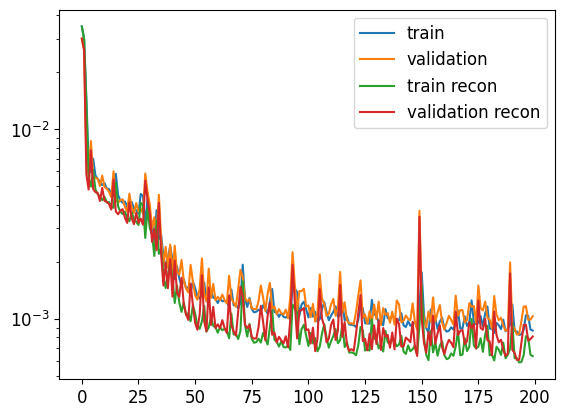

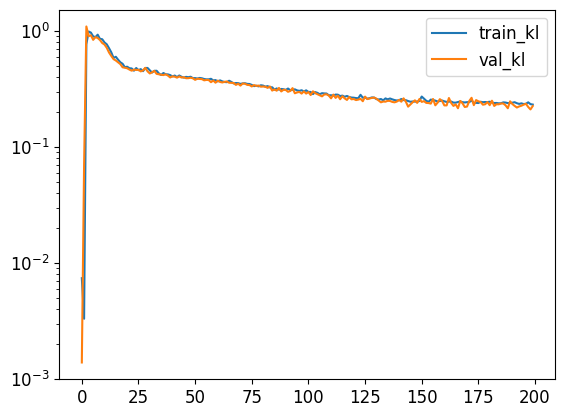

In [12]:

history = train_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    device=device,
)

train_losses = history["train_loss"]
val_losses = history["val_loss"]
train_recon_losses = history["train_recon"]
val_recon_losses = history["val_recon"]
train_kl = history["train_kl"]
val_kl = history["val_kl"]


# -------------------------
# Loss curves
# -------------------------
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.plot(train_recon_losses, label="train recon")
plt.plot(val_recon_losses, label="validation recon")
plt.yscale("log")
plt.legend()
plt.show()

# -------------------------
# KL curves
# -------------------------
plt.figure()
plt.plot(train_kl, label="train_kl")
plt.plot(val_kl, label="val_kl")
plt.yscale("log")
plt.legend()
plt.show()

In [13]:
# Check latent usage in DIVA

batch = next(iter(test_loader))

x = batch["input"].to(device)
y = batch["output"].to(device)

model.eval()

with torch.no_grad():
    out = model(x, y)

print("z statistics")
print("mu_z std      :", out["mu_z"].std())
print("logvar_z mean :", out["logvar_z"].mean())


z statistics
mu_z std      : tensor(0.3712)
logvar_z mean : tensor(-0.4859)


In [8]:

def save_config(save_dir, config):
    with open(
        os.path.join(save_dir, "model_config.json"), "w", encoding="utf-8"
    ) as f:
        json.dump(config, f, ensure_ascii=False, indent=4)


SAVE_NAME   = f"model_{datetime.now():%Y%m%d_%H%M%S}_cvaea"
SAVE_DIR    = os.path.join("/scratch/project_2009007/ambrunc/dev_karhu/karhu/models", SAVE_NAME)
os.makedirs(SAVE_DIR, exist_ok=False)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "model.pt"))
dataset.save_scaling_params(SAVE_DIR)
config = data_config | model_config
save_config(SAVE_DIR, config)

{'mse': np.float32(0.0040833605), 'mae': np.float32(0.038290262), 'mape': 0.0, 'r2': 0.8227387070655823}
{'mse': np.float32(0.00037783338), 'mae': np.float32(0.011647417), 'mape': 0.0, 'r2': 0.8227402567863464}


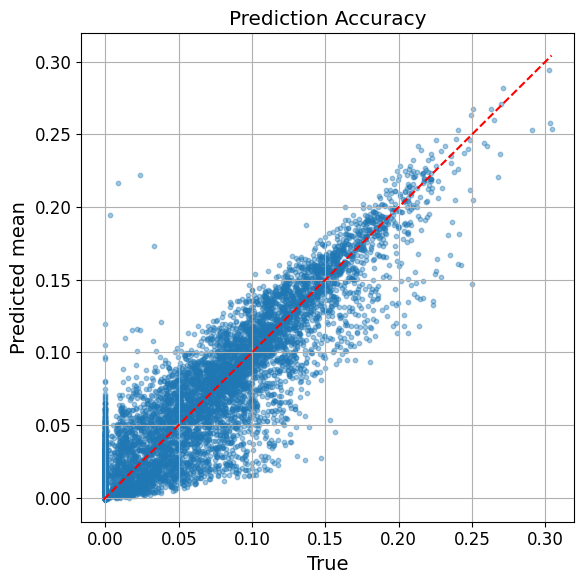

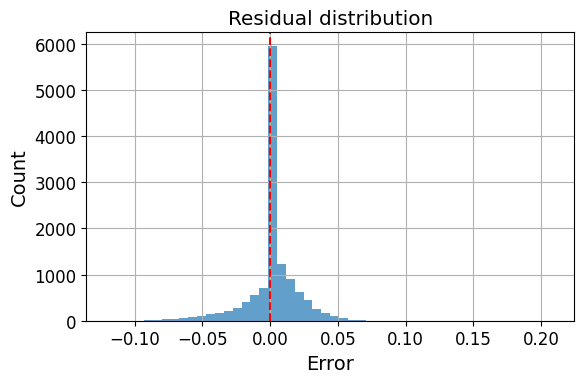

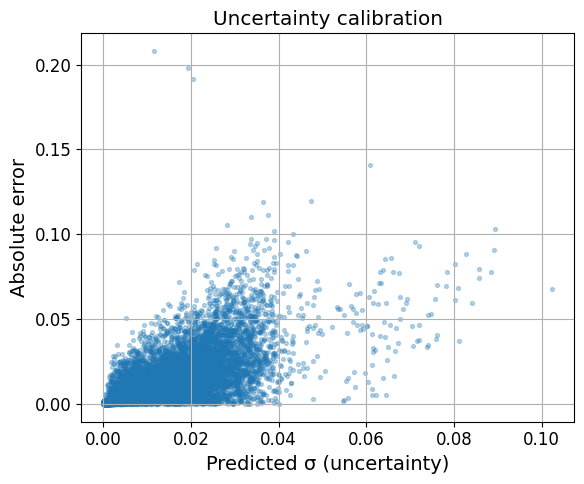

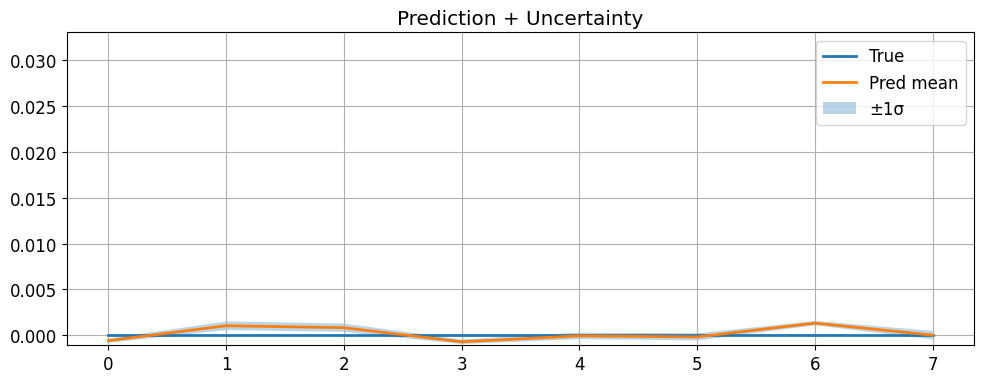

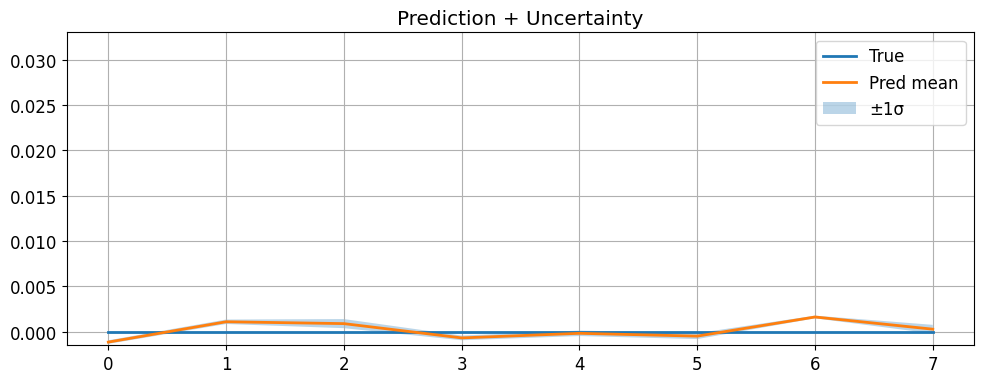

...

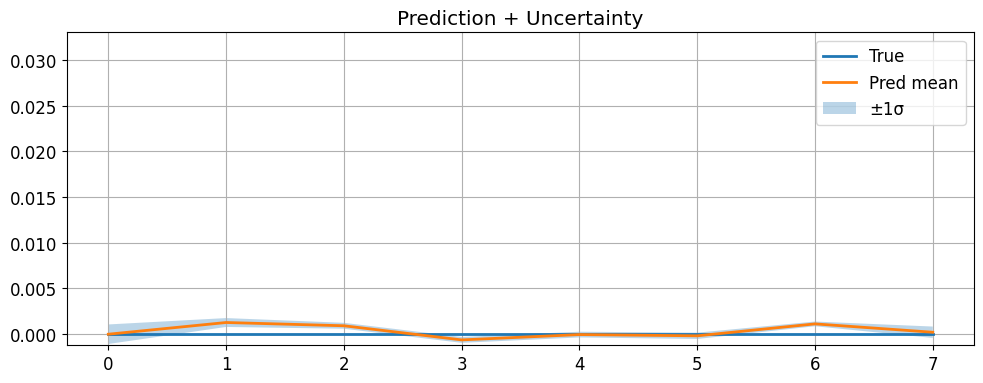

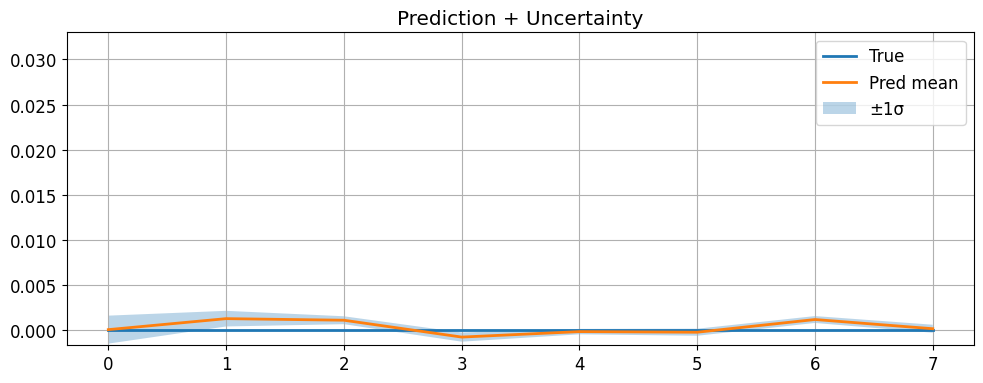

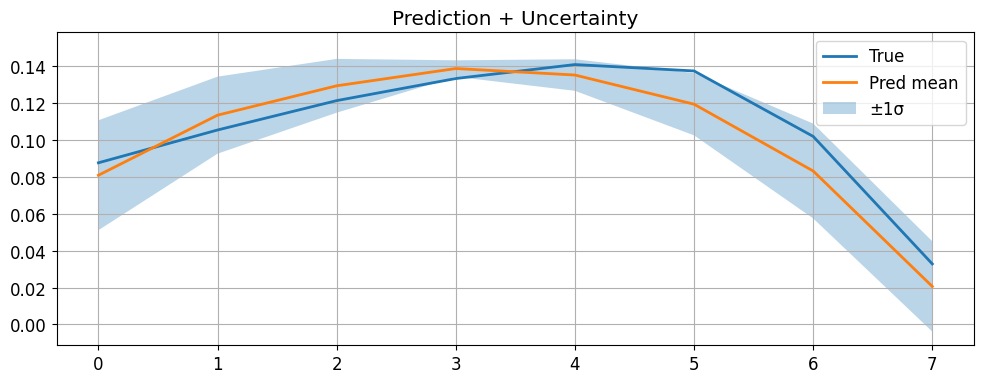

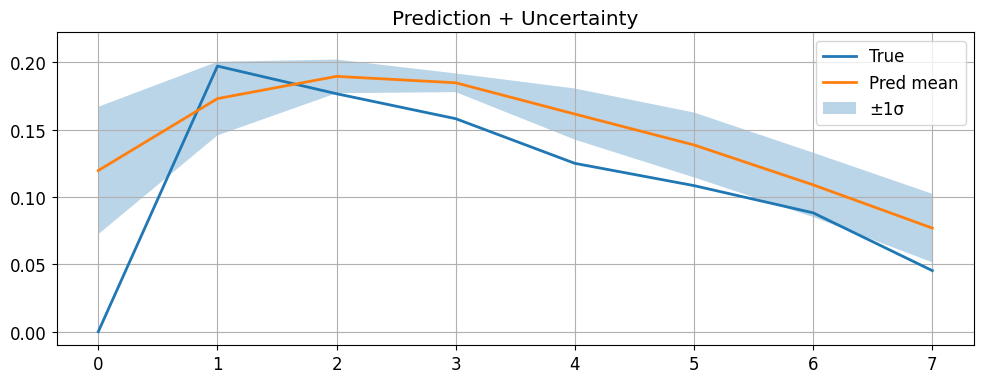

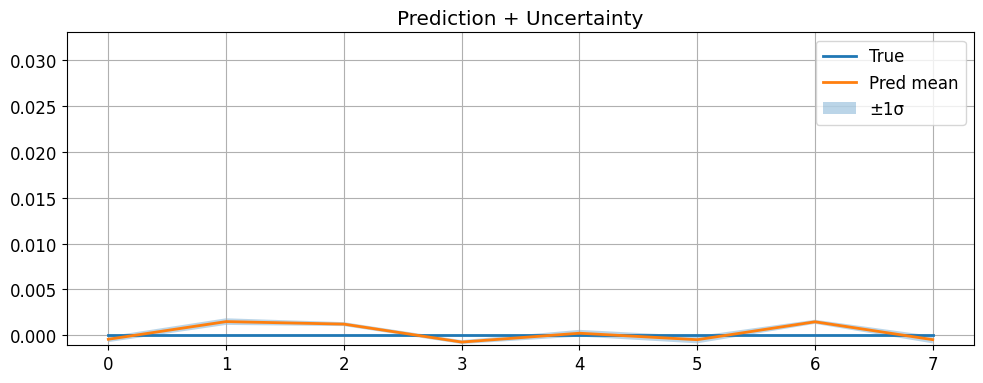

In [14]:
x_batch = next(iter(test_loader))["input"].to(device)
y_true = next(iter(test_loader))["output"].to(device)

y_mean, y_std = predict(
    model,
    x_batch,
    n_samples=100,
    # device=device,
)

y_mean = y_mean.cpu().numpy()
y_std = y_std.cpu().numpy()
y_true = y_true.cpu().numpy()

print(get_regression_scores(y_true, y_mean))

y_mean = dataset.descale_minmax(
    y_mean,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

y_std = dataset.descale_minmax(
    y_std,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

y_true = dataset.descale_minmax(
    y_true,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

print(get_regression_scores(y_true, y_mean))

plot_scatter(y_true, y_mean)
plot_residuals(y_true, y_mean)
plot_uncertainty_calibration(y_true, y_mean, y_std)

plot_random_predictions(
    y_true,
    y_mean,
    y_std,
    n_examples=50,
)


## DIVA

In [16]:

from karhu.gntor_diva import GNtorPredictor, setup_dataset
from karhu.gntor_diva import train_model, predict, split_dataset, evaluate_diva

In [17]:

model_config = {
    "x_dim": 3*64+128+2,
    "y_dim": 8,
    "latent_x": 30,
    "latent_y": 10,
    "hidden_dims": (256,256,128,128,)
}
model = GNtorPredictor(**model_config)


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-4,
)

device = 'cpu'
dataset_dir = "/scratch/project_2009007/ambrunc/dev_karhu/karhu/db/jet_2H/interpolated64.h5"
batch_size = 500
dataset, data_config = setup_dataset(dir_path=dataset_dir)

test_ratio = 0.10
train_ratio = 0.70
val_ratio = 0.20
train_data, val_data, test_data = split_dataset(
    dataset, train_ratio, val_ratio, test_ratio, base_seed=42)
    
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data), shuffle=False)

Epoch   1/200 | train=0.036918 | val=0.031476 | recon=0.036918 | kl_x=0.004136 | kl_y=0.003441 | time=1.9s
Epoch   2/200 | train=0.032429 | val=0.030914 | recon=0.032429 | kl_x=0.002687 | kl_y=0.004067 | time=1.2s
Epoch   3/200 | train=0.030667 | val=0.023994 | recon=0.030655 | kl_x=0.002974 | kl_y=0.305444 | time=4.5s
Epoch   4/200 | train=0.014204 | val=0.008740 | recon=0.014122 | kl_x=0.029761 | kl_y=1.359208 | time=1.5s
Epoch   5/200 | train=0.006424 | val=0.005197 | recon=0.006210 | kl_x=0.211940 | kl_y=2.648028 | time=6.0s
Epoch   6/200 | train=0.005189 | val=0.004758 | recon=0.004907 | kl_x=0.630316 | kl_y=2.759403 | time=1.2s
Epoch   7/200 | train=0.004873 | val=0.004490 | recon=0.004542 | kl_x=1.121846 | kl_y=2.649988 | time=2.5s
Epoch   8/200 | train=0.004729 | val=0.005064 | recon=0.004367 | kl_x=1.381600 | kl_y=2.450227 | time=2.2s
Epoch   9/200 | train=0.004672 | val=0.004389 | recon=0.004299 | kl_x=1.446953 | kl_y=2.189476 | time=3.5s
Epoch  10/200 | train=0.004412 | val=

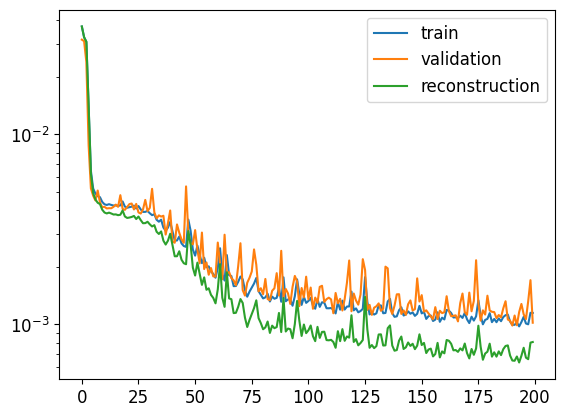

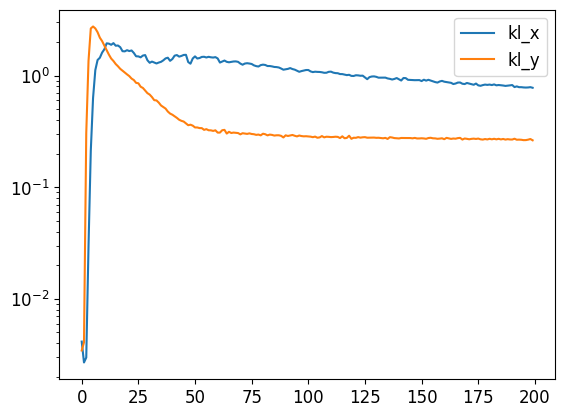

In [18]:
history = train_model(
    model,
    optimizer,
    train_loader,
    val_loader,
    epochs=200,
    device=device,
)

train_losses = history["train_loss"]
val_losses = history["val_loss"]
recon_losses = history["recon_loss"]
kl_x = history["kl_x"]
kl_y = history["kl_y"]

# -------------------------
# Loss curves
# -------------------------
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="validation")
plt.plot(recon_losses, label="reconstruction")
plt.yscale("log")
plt.legend()
plt.show()

# -------------------------
# KL curves
# -------------------------
plt.figure()
plt.plot(kl_x, label="kl_x")
plt.plot(kl_y, label="kl_y")
plt.yscale("log")
plt.legend()
plt.show()

In [19]:
# Check latent usage in DIVA

batch = next(iter(test_loader))

x = batch["input"].to(device)
y = batch["output"].to(device)

model.eval()

with torch.no_grad():
    out = model(x, y)

print("z_x statistics")
print("mu_x std      :", out["mu_x"].std())
print("logvar_x mean :", out["logvar_x"].mean())

print()

print("z_y statistics")
print("mu_y std      :", out["mu_y"].std())
print("logvar_y mean :", out["logvar_y"].mean())

z_x statistics
mu_x std      : tensor(0.5901)
logvar_x mean : tensor(-1.9236)

z_y statistics
mu_y std      : tensor(0.3595)
logvar_y mean : tensor(-0.5314)


In [ ]:

def save_config(save_dir, config):
    with open(
        os.path.join(save_dir, "model_config.json"), "w", encoding="utf-8"
    ) as f:
        json.dump(config, f, ensure_ascii=False, indent=4)


SAVE_NAME   = f"model_{datetime.now():%Y%m%d_%H%M%S}_diva"
SAVE_DIR    = os.path.join("/scratch/project_2009007/ambrunc/dev_karhu/karhu/models", SAVE_NAME)
os.makedirs(SAVE_DIR, exist_ok=False)

torch.save(model.state_dict(), os.path.join(SAVE_DIR, "model.pt"))
dataset.save_scaling_params(SAVE_DIR)
config = data_config | model_config
save_config(SAVE_DIR, config)

{'mse': np.float32(0.026865538), 'mae': np.float32(0.12050892), 'mape': 0.0, 'r2': 0.2845483720302582}
{'mse': np.float32(0.0024858683), 'mae': np.float32(0.036657304), 'mape': 0.0, 'r2': 0.28455355763435364}


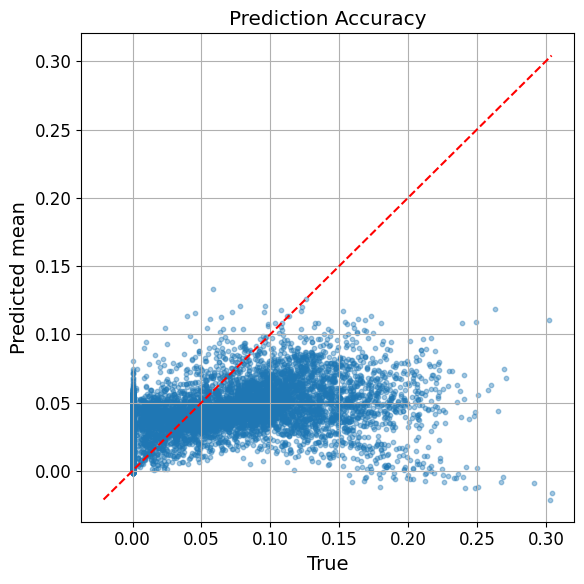

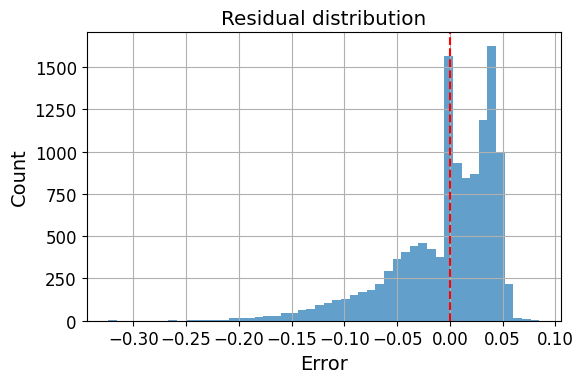

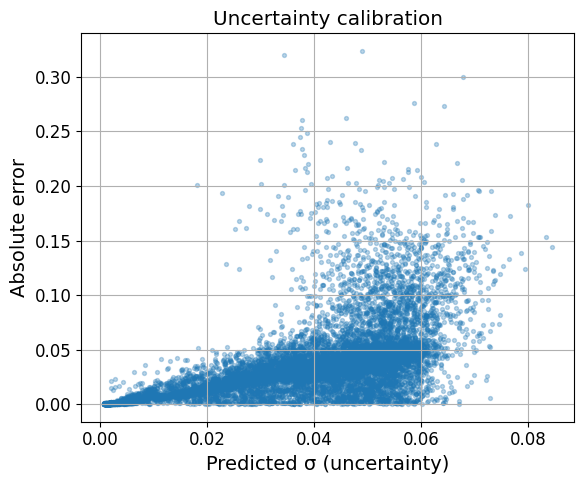

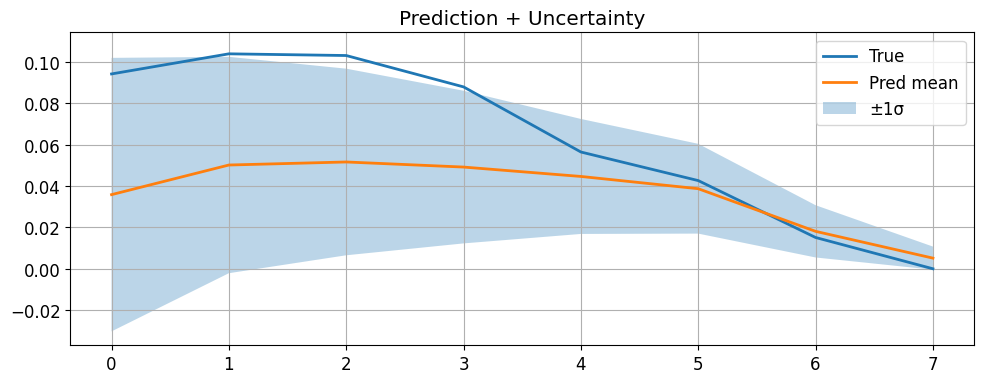

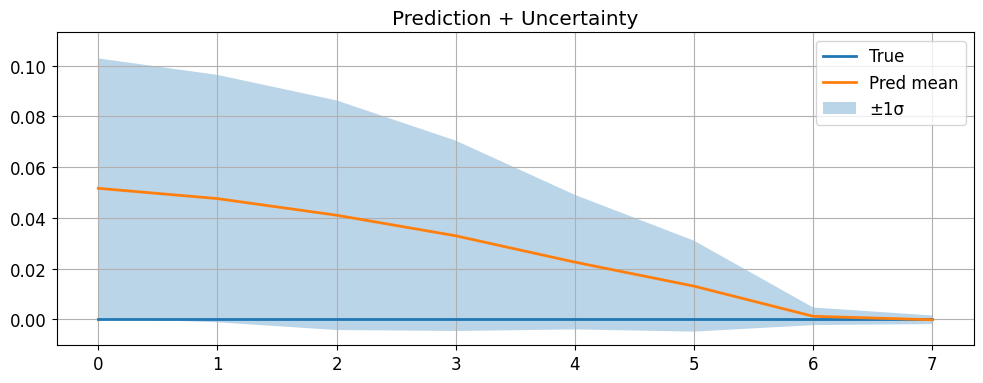

...

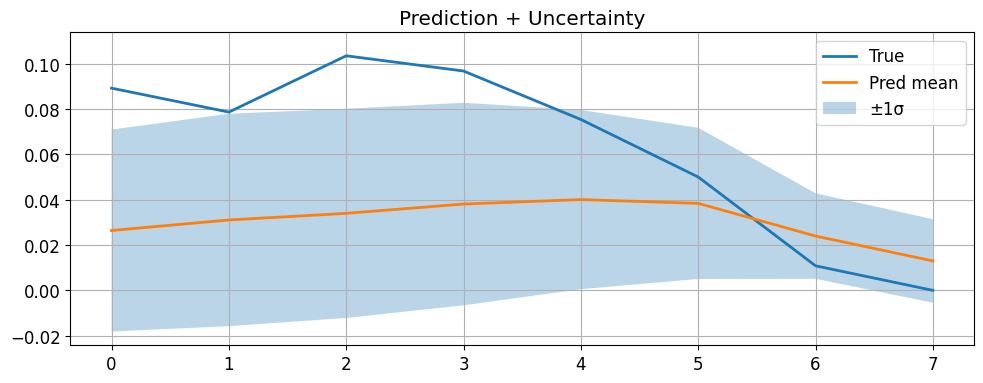

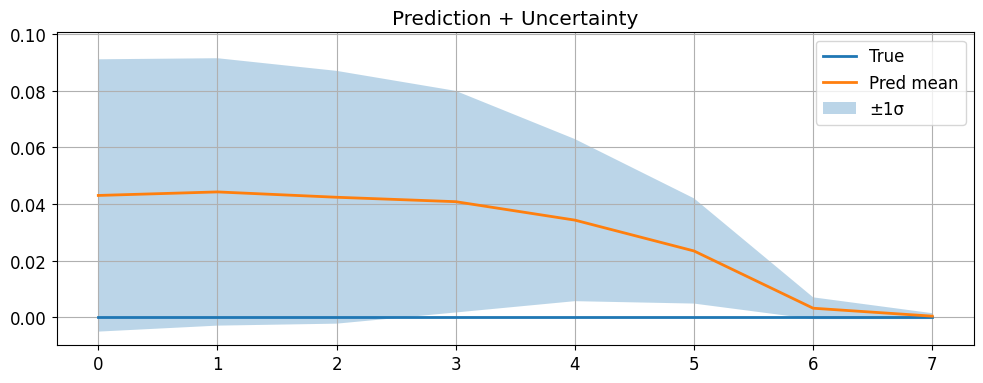

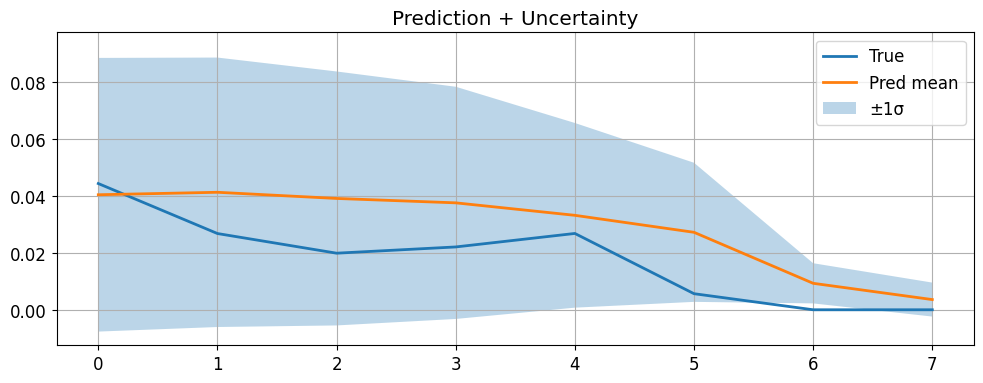

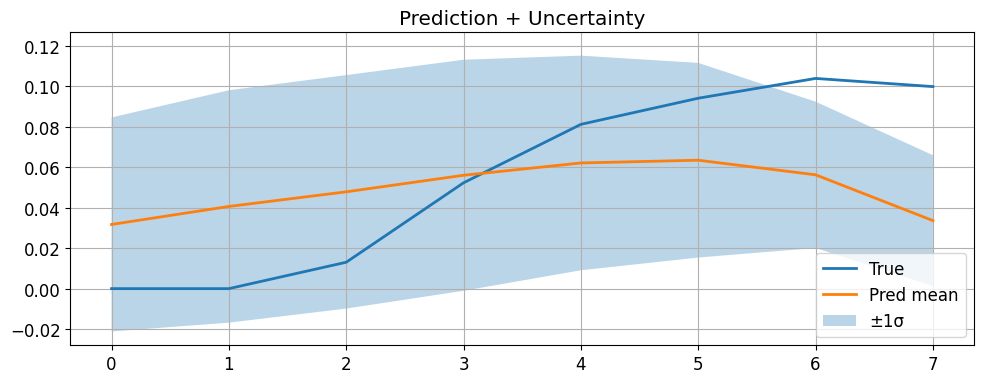

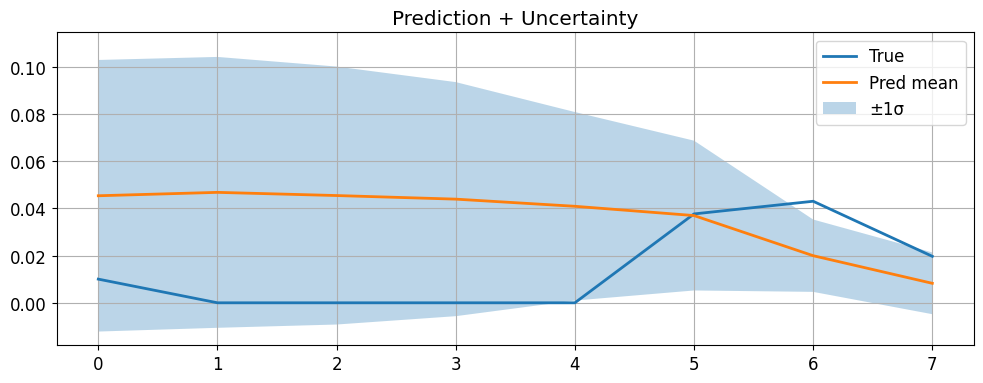

In [20]:
x_batch = next(iter(test_loader))["input"].to(device)
y_true = next(iter(test_loader))["output"].to(device)

y_mean, y_std = predict(
    model,
    x_batch,
    n_samples=100,
    # device=device,
)

y_mean = y_mean.cpu().numpy()
y_std = y_std.cpu().numpy()
y_true = y_true.cpu().numpy()

print(get_regression_scores(y_true, y_mean))

y_mean = dataset.descale_minmax(
    y_mean,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

y_std = dataset.descale_minmax(
    y_std,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

y_true = dataset.descale_minmax(
    y_true,
    dataset.scaling_params["growthrate"][0],
    dataset.scaling_params["growthrate"][1],
)

print(get_regression_scores(y_true, y_mean))

plot_scatter(y_true, y_mean)
plot_residuals(y_true, y_mean)
plot_uncertainty_calibration(y_true, y_mean, y_std)
plot_random_predictions(
    y_true,
    y_mean,
    y_std,
    n_examples=50,
)
